In [ ]:
# Relevant pip installs
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install lightgbm
!pip install fairlearn

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, f1_score, precision_score, recall_score

import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

from fairlearn.metrics import MetricFrame
from fairlearn.metrics import (demographic_parity_difference, demographic_parity_ratio,
                               selection_rate_difference, false_negative_rate_difference,
                               false_positive_rate_difference, equalized_odds_ratio,
                               false_negative_rate, false_positive_rate)

In [ ]:
# Read feature matrix
#!unzip feature_matrix.zip
feature_matrix = pd.read_csv('feature_matrix.csv')
feature_matrix.head()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,...,MODE(installments.previous.NAME_GOODS_CATEGORY)_XNA,MODE(installments.previous.NAME_PAYMENT_TYPE)_Cash through the bank,MODE(installments.previous.NAME_PRODUCT_TYPE)_walk-in,MODE(installments.previous.NAME_PRODUCT_TYPE)_x-sell,MODE(installments.previous.PRODUCT_COMBINATION)_Card Street,MODE(installments.previous.PRODUCT_COMBINATION)_Card X-Sell,MODE(installments.previous.PRODUCT_COMBINATION)_Cash X-Sell: low,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_THURSDAY,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_TUESDAY,MODE(installments.previous.WEEKDAY_APPR_PROCESS_START)_WEDNESDAY
0,100002,0.0,0.207607,0.090287,0.090032,0.256321,1.0,1.0,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,100003,0.0,0.286846,0.311736,0.132924,0.045016,1.0,1.0,0.0,1.0,...,False,True,False,False,False,False,False,False,False,False
2,100004,0.0,0.049128,0.022472,0.020025,0.134897,1.0,1.0,1.0,1.0,...,False,True,False,False,False,False,False,False,False,False
3,100006,0.0,0.128368,0.066837,0.109477,0.107023,1.0,1.0,0.0,1.0,...,False,True,False,False,False,False,False,False,False,False
4,100007,0.0,0.112520,0.116854,0.078975,0.392880,1.0,1.0,0.0,1.0,...,True,True,False,True,False,False,False,False,False,False


# Train-test split

In [ ]:
#splitting application_train_newdf into train and test
train,test = train_test_split(feature_matrix,test_size=.25,random_state = 123)

#separating dependent and independent variables (no under/over sampling)
train_X = train[[i for i in train.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
train_Y = train[["TARGET"]]

test_X  = test[[i for i in test.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
test_Y  = test[["TARGET"]]

In [ ]:
# Down-sample Majority Class

count = train['TARGET'].value_counts()
num_majority = count[0]
num_minority = count[1]

#Number of undersampled majority class 2 x minority class
num_undersample_majority = 2 * num_minority

#separating majority and minority classes
df_majority = train[train["TARGET"] == 0]
df_minority = train[train["TARGET"] == 1]

df_majority_undersampled = resample(df_majority, replace=False,
                                   n_samples=num_undersample_majority,
                                   random_state=123)

df_undersampled = pd.concat([df_minority,df_majority_undersampled],axis=0)

#splitting dependent and independent variables

df_undersampled_X = df_undersampled[[i for i in df_undersampled.columns if i not in ['SK_ID_CURR'] + [ 'TARGET']]]
df_undersampled_Y = df_undersampled[["TARGET"]]

# Train ADS

In [ ]:
# Train ADS

# Split
x_train, x_eval, y_train, y_eval = train_test_split(df_undersampled_X, df_undersampled_Y, test_size=0.2, random_state=42)

# Clean column names
x_train = x_train.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
x_eval = x_eval.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
test_X = test_X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))
test_X = test_X[x_train.columns]

# Model
model = lgb.LGBMClassifier(
    n_estimators=10000,
    objective='binary',
    class_weight='balanced',
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=0.1,
    subsample=0.8,
    n_jobs=-1,
    random_state=50,
    verbose=-1
)

# Callbacks
callbacks = [
    early_stopping(stopping_rounds=200, verbose=True),
    log_evaluation(period=1)
]

# Train
model.fit(
    x_train,
    y_train,
    eval_set=[(x_eval, y_eval)],
    eval_names=['valid'],
    eval_metric='auc',
    callbacks=callbacks
)

# Predict
predictions = model.predict(test_X)
prediction_probabilities = model.predict_proba(test_X)[:, 1]

[1]	valid's auc: 0.712734	valid's binary_logloss: 0.686033
Training until validation scores don't improve for 200 rounds
[2]	valid's auc: 0.716015	valid's binary_logloss: 0.679646
[3]	valid's auc: 0.720299	valid's binary_logloss: 0.673755
[4]	valid's auc: 0.721423	valid's binary_logloss: 0.66844
[5]	valid's auc: 0.722909	valid's binary_logloss: 0.663502
[6]	valid's auc: 0.724923	valid's binary_logloss: 0.658914
[7]	valid's auc: 0.726197	valid's binary_logloss: 0.654713
[8]	valid's auc: 0.72722	valid's binary_logloss: 0.650961
[9]	valid's auc: 0.728842	valid's binary_logloss: 0.647358
[10]	valid's auc: 0.729957	valid's binary_logloss: 0.643951
[11]	valid's auc: 0.730436	valid's binary_logloss: 0.641046
[12]	valid's auc: 0.731643	valid's binary_logloss: 0.637995
[13]	valid's auc: 0.732283	valid's binary_logloss: 0.635411
[14]	valid's auc: 0.73288	valid's binary_logloss: 0.632941
[15]	valid's auc: 0.733248	valid's binary_logloss: 0.630724
[16]	valid's auc: 0.733804	valid's binary_logloss:

# Feature Importance and Input Distributions

In [ ]:
# Find most important features
features = model.feature_name_
raw_importance = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': raw_importance / raw_importance.sum()
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                                            Feature  Importance
17                                     EXT_SOURCE_1    0.029000
62                                      CREDIT_TERM    0.027222
19                                     EXT_SOURCE_3    0.023889
18                                     EXT_SOURCE_2    0.023556
56                                              AGE    0.013444
641            PERCENTILEMINinstallmentsAMT_PAYMENT    0.012667
3                                       AMT_ANNUITY    0.012111
368  MAXpreviousPERCENTILEDAYS_LAST_DUE_1ST_VERSION    0.011889
57                                   YEARS_EMPLOYED    0.008111
649                                   CODE_GENDER_F    0.007889


Here we will plot the 5 most important features.

In [ ]:
# Read raw data
application_data = pd.read_csv('application_train.csv')

# Recreate author created CREDIT_TERM column
application_data['CREDIT_TERM'] = application_data['AMT_ANNUITY'] / application_data['AMT_CREDIT']

application_data.shape

(307511, 123)

In [ ]:
def create_day_to_year(df,ls_cols,newcol):
    df[newcol] = round(np.abs(df[ls_cols[0]]/365))
    df.drop(columns=ls_cols,inplace=True);
    return df

In [ ]:
#Create AGE column in years
create_day_to_year(application_data,['DAYS_BIRTH'],'AGE')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_TERM,AGE
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.060749,26.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.027598,46.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.050000,52.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.094941,52.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.042623,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.108198,26.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.044524,57.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.044239,41.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.054592,33.0


In [ ]:
important_features = application_data[['EXT_SOURCE_1', 'CREDIT_TERM', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE', 'CODE_GENDER', 'TARGET']]
important_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   EXT_SOURCE_1  134133 non-null  float64
 1   CREDIT_TERM   307499 non-null  float64
 2   EXT_SOURCE_2  306851 non-null  float64
 3   EXT_SOURCE_3  246546 non-null  float64
 4   AGE           307511 non-null  float64
 5   CODE_GENDER   307511 non-null  object 
 6   TARGET        307511 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 16.4+ MB


In [ ]:
important_features.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


We can see that

In [ ]:
important_features.head()

,EXT_SOURCE_1,CREDIT_TERM,EXT_SOURCE_2,EXT_SOURCE_3,AGE,CODE_GENDER,TARGET
0,0.083037,0.060749,0.262949,0.139376,26.0,M,1
1,0.311267,0.027598,0.622246,NaN,46.0,F,0
2,NaN,0.050000,0.555912,0.729567,52.0,M,0
3,NaN,0.094941,0.650442,NaN,52.0,F,0
4,NaN,0.042623,0.322738,NaN,55.0,M,0


In [ ]:
#function to plot distributions
def plot_distributions_on_axis(df, feature, ax):
    defaulted = df[df['TARGET'] == 1]
    non_defaulted = df[df['TARGET'] == 0]

    sns.kdeplot(df[feature], fill=True, alpha=.3, color='blue', label='Overall', linewidth=2, ax=ax)
    sns.kdeplot(defaulted[feature], fill=True, alpha=.3, color='red', label='Defaulted', linewidth=2, ax=ax)
    sns.kdeplot(non_defaulted[feature], fill=True, alpha=.3, color='green', label='Non-Defaulted', linewidth=2, ax=ax)

    ax.legend()
    ax.set_title(f'Distribution of {feature}')

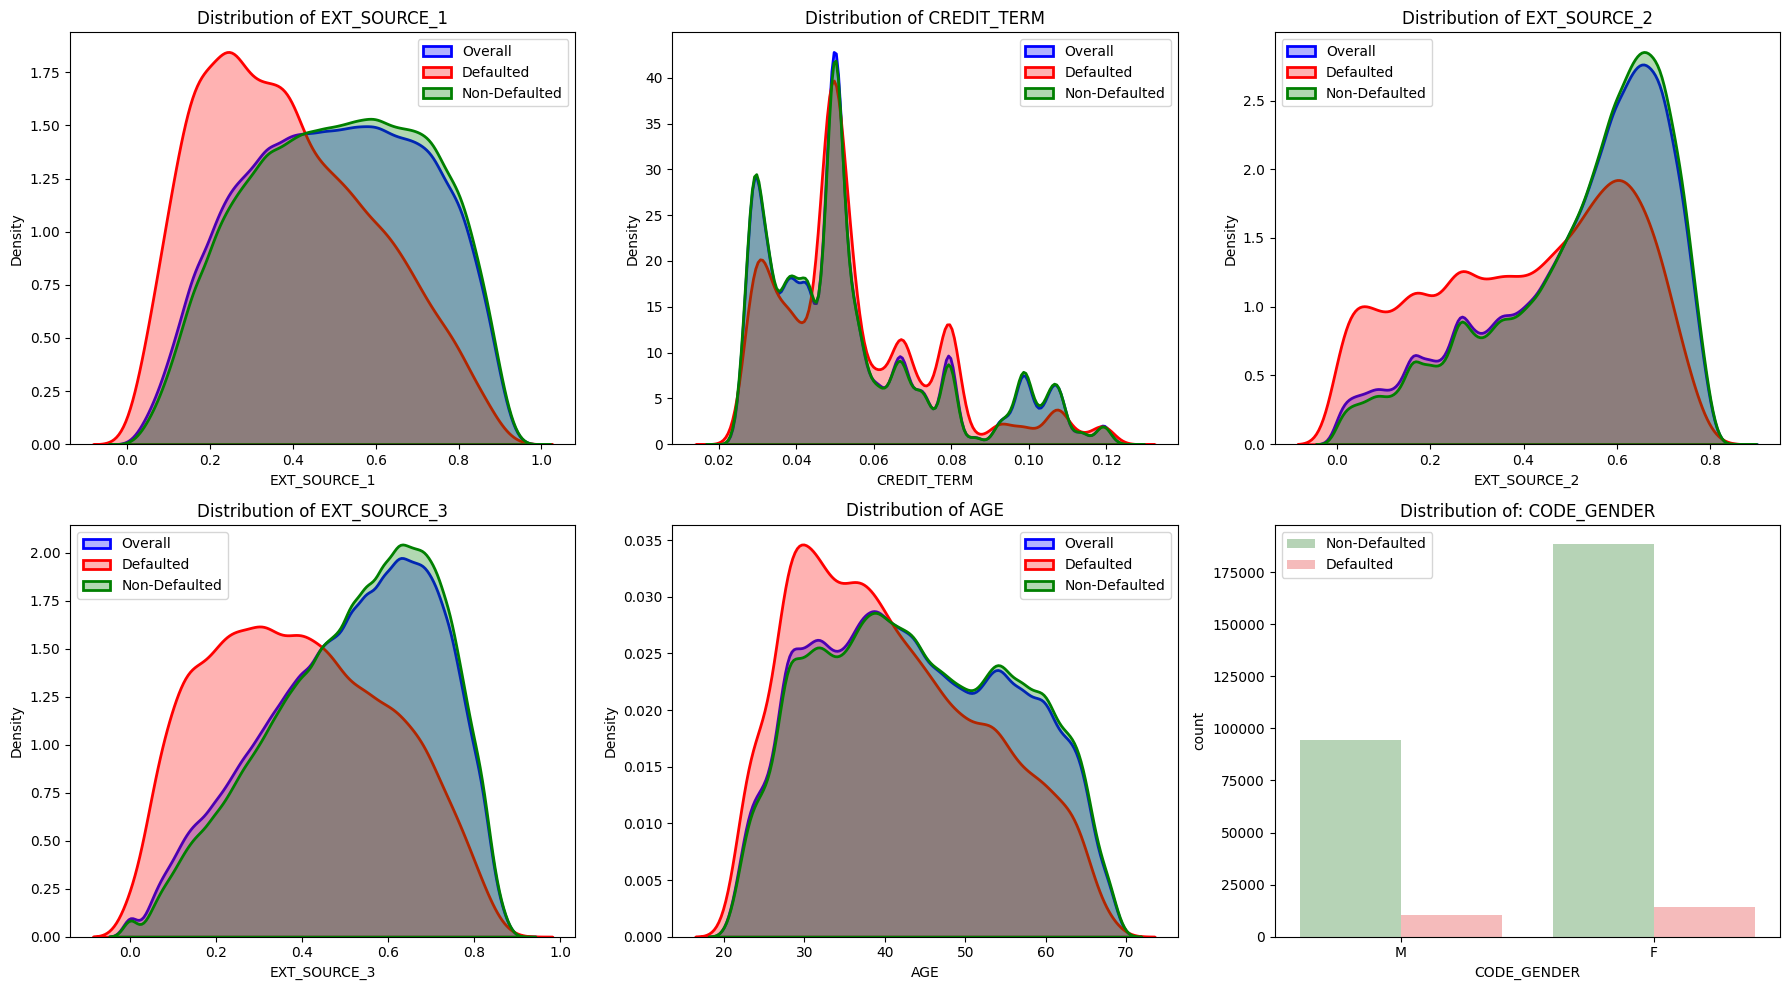

In [ ]:
# plot distributions
import_feat_cols = important_features.columns[:5]
fig, axes = plt.subplots(figsize=(18,10), nrows=2, ncols=3)
axes = axes.flatten()

for i, feature in enumerate(import_feat_cols):
    plot_distributions_on_axis(important_features, feature, axes[i])

gender_cleaned = important_features[important_features['CODE_GENDER'] != 'XNA']

sns.countplot(data=gender_cleaned, x='CODE_GENDER', hue='TARGET', ax=axes[5], palette={0: 'green', 1: 'red'}, alpha=0.3)
axes[5].set_title('Distribution of: CODE_GENDER')
axes[5].legend(labels=['Non-Defaulted', 'Defaulted'])

plt.tight_layout()
plt.show()
plt.close()

In [ ]:
important_features['CODE_GENDER'] = important_features['CODE_GENDER'].map({'M':0, 'F':1})

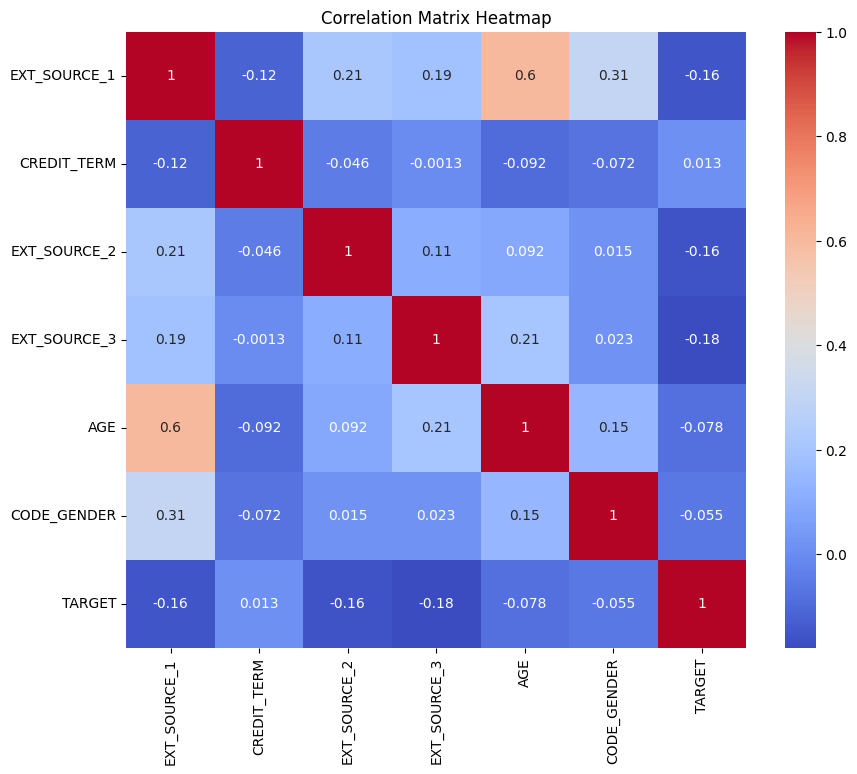

<Figure size 800x600 with 0 Axes>

In [ ]:
#plot correlations
corr = important_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.figure(figsize=(8, 6))
plt.show()
plt.close()

In [ ]:
# find class balance for TARGET
class_balance = important_features['TARGET'].value_counts()
print(class_balance)
class_balance/class_balance.sum()

TARGET
0    282686
1     24825
Name: count, dtype: int64


,count
TARGET,
0,0.919271
1,0.080729


We observe a major class imbalance with only 8% of the data defaulting on a loan.

# Fairness Metrics

In [ ]:
# define sensitive features and metric frame

sensitive_features_sex = test_X['CODE_GENDER_F'].replace({0: 'Men', 1: 'Women'})

metric_dict = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'fnr': false_negative_rate,
    'fpr': false_positive_rate,
}

def calculate_metrics(y_pred, y_true, metric_dict, sensitive_features):
  metric_frame = MetricFrame( metrics=metric_dict,
                              y_true=y_true,
                              y_pred=y_pred,
                              sensitive_features=sensitive_features
                            )
  return metric_frame

In [ ]:
# Print results
model_metrics = calculate_metrics(predictions, test_Y, metric_dict, sensitive_features_sex)
print(model_metrics.overall)

print(model_metrics.by_group)

accuracy     0.726320
precision    0.184825
recall       0.690860
fnr          0.309140
fpr          0.270532
dtype: float64
               accuracy  precision    recall       fnr       fpr
CODE_GENDER_F                                                   
False          0.650991   0.192250  0.760254  0.239746  0.361370
True           0.765692   0.178686  0.638974  0.361026  0.224617


In [ ]:
# Calculate fairness metrics
fpr_diff = false_positive_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
fnr_diff = false_negative_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
sr_diff = selection_rate_difference(test_Y, predictions, sensitive_features=sensitive_features_sex)
dp_ratio = demographic_parity_ratio(test_Y, predictions, sensitive_features=sensitive_features_sex)
eo_ratio = equalized_odds_ratio(test_Y, predictions, sensitive_features=sensitive_features_sex)

model_fairness_metrics = pd.Series( data={'fpr difference': fpr_diff,
                                          'fnr difference': fnr_diff,
                                          'selection rate diff.': sr_diff,
                                          'demo. parity ratio': dp_ratio,
                                          'equalized odds ratio': eo_ratio,
                                          }
                                  )
print(model_fairness_metrics)

fpr difference          0.136753
fnr difference          0.121279
selection rate diff.    0.147855
demo. parity ratio      0.632120
equalized odds ratio    0.621571
dtype: float64


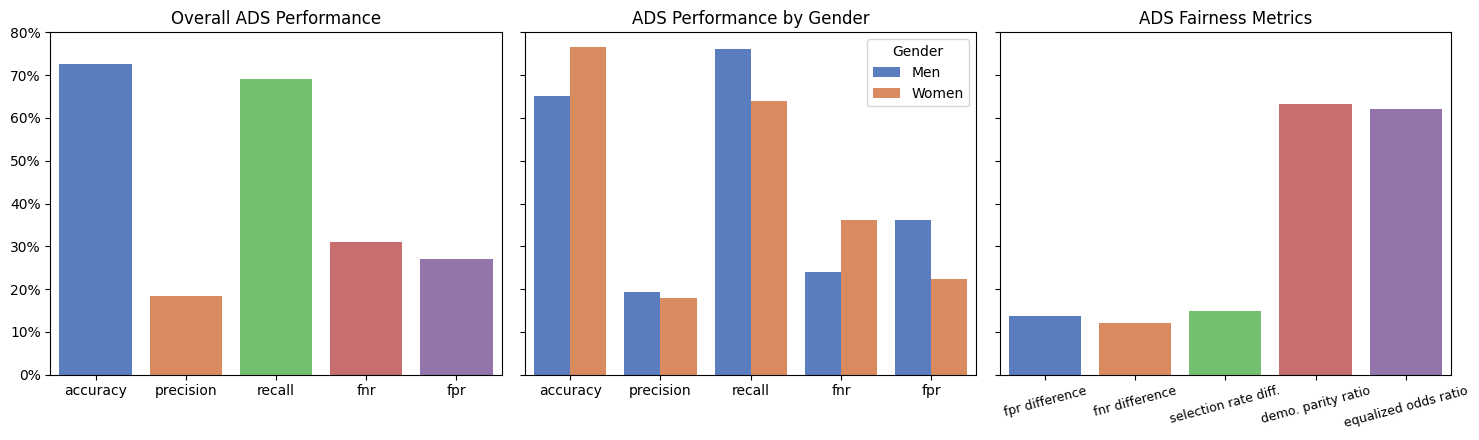

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4.5), sharey=True)

# plot for overall results
overall_metrics = model_metrics.overall

sns.barplot(x=overall_metrics.index, y=overall_metrics.values, ax=axes[0], palette='muted')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[0].set_title('Overall ADS Performance')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# compare results by gender
metrics_df = model_metrics.by_group.reset_index()
metrics_df['CODE_GENDER_F'] = metrics_df['CODE_GENDER_F'].map({True: 'Women', False: 'Men'})
shaped_df = metrics_df.melt(id_vars='CODE_GENDER_F',
                            var_name='Metric',
                            value_name='Score')
shaped_df.rename(columns={'CODE_GENDER_F': 'Gender'}, inplace=True)

sns.barplot(data=shaped_df, x='Metric', y='Score', hue='Gender', palette='muted', ax=axes[1])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[1].set_title('ADS Performance by Gender')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

# Plot fairness metrics
sns.barplot(x=model_fairness_metrics.index, y=model_fairness_metrics.values, ax=axes[2], palette='muted')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
axes[2].set_title('ADS Fairness Metrics')
axes[2].tick_params(axis='x', rotation=15, labelsize=9)
axes[2].set_xlabel('')
axes[2].set_ylabel('')

plt.setp(axes, ylim=(0, 0.8))
plt.tight_layout()
plt.savefig('metrics.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()